In [17]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file = pd.read_csv("D:/BOX/Box Sync/RA/data/SPEC/Toma/probabilities.csv")
file

,Sample,BSIM,CALB,CKOS,CPAR,CTRO,ECOL,KRHI,MLUT,MOSL,PAER,PMIR,SCAP,SEPI,SHOM,SWAR,Actual
0,AZ008_0000570_20190228,0.0000,0.0000,0.9925,0.0000,0.0,0.0025,0.0000,0.000,0.0000,0.0000,0.0050,0.0000,0.0,0.0000,0.0000,CKOS
1,AZ008_0000988_20190228,0.0000,0.0000,0.0525,0.0000,0.0,0.9200,0.0025,0.000,0.0000,0.0025,0.0225,0.0000,0.0,0.0000,0.0000,ECOL
2,AZ008_0000990_20190228,0.0000,0.0000,0.0175,0.0000,0.0,0.9675,0.0000,0.000,0.0000,0.0000,0.0150,0.0000,0.0,0.0000,0.0000,ECOL
3,AZ008_0000997_20190228,0.0000,0.0000,0.0125,0.0000,0.0,0.9625,0.0000,0.000,0.0000,0.0150,0.0100,0.0000,0.0,0.0000,0.0000,ECOL
4,AZ008_0000998_20190228,0.0000,0.0025,0.1250,0.0000,0.0,0.7550,0.0025,0.000,0.0000,0.0125,0.1025,0.0000,0.0,0.0000,0.0000,ECOL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,AZ008_AZ01401_20190228,0.9925,0.0000,0.0000,0.0000,0.0,0.0000,0.0025,0.005,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,BSIM
146,AZ008_AZ01402_20190228,1.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,BSIM
147,AZ008_AZ01446_20190228,0.9925,0.0000,0.0025,0.0000,0.0,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0,0.0025,0.0025,BSIM
148,AZ008_AZ01490_20190228,0.9550,0.0000,0.0150,0.0000,0.0,0.0100,0.0000,0.010,0.0000,0.0000,0.0075,0.0000,0.0,0.0025,0.0000,BSIM


In [15]:
cm_label = np.unique(file.iloc[:,1:-1].columns)

all_y = file['Actual'].values
all_probs = file.iloc[:,1:-1].values

all_y = np.array(all_y)
all_probs = np.array(all_probs)
# all_probs_np = []
# for i in range(len(Data_r1)):
#     all_probs_np.append(np.array(all_probs[i]))
n_classes = len(cm_label)
print('Total classes = ' +str(n_classes))


TPRs = dict()
FPRs = dict()
AUCs = dict()
for i in range(n_classes):
#     FPRs[i], TPRs[i], _ = roc_curve(all_y,all_probs[:,0,i],pos_label=cm_label[i])
    FPRs[i], TPRs[i], _ = roc_curve(all_y,all_probs[:,i],pos_label=cm_label[i])

    AUCs[i] = auc(FPRs[i], TPRs[i])
    
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([FPRs[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, FPRs[i], TPRs[i])

# Finally average it and compute AUC
mean_tpr /= n_classes
mean_tpr[0] = 0.0

FPRs["macro"] = all_fpr
TPRs["macro"] = mean_tpr
AUCs["macro"] = auc(FPRs["macro"], TPRs["macro"])

Total classes = 15


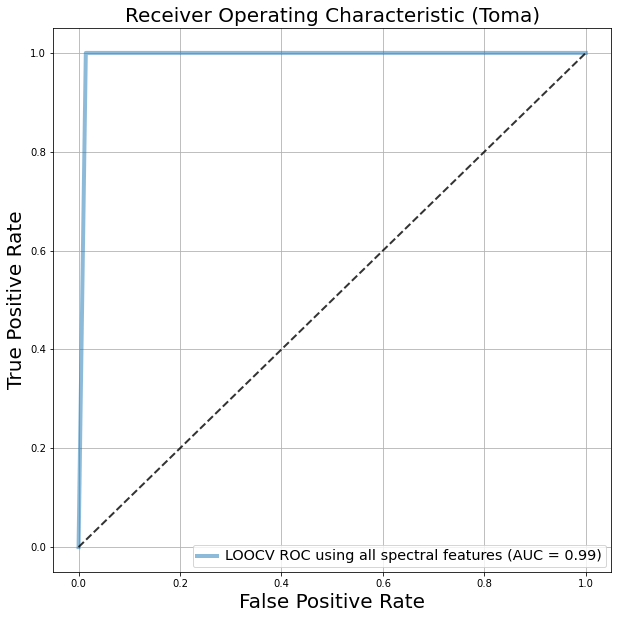

In [27]:
plt.figure(1, figsize=(10,10))
plt.plot(FPRs['macro'], TPRs['macro'], lw=4, alpha=0.5, label='LOOCV ROC using all spectral features (AUC = %0.2f)' % (AUCs['macro']))
# plt.plot(FPRs[5], TPRs[5], lw=4, alpha=0.5, label='LOOCV ROC using all spectral features (AUC = %0.2f)' % (AUCs[5]))
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='k', alpha=.8)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate',fontsize=20)
plt.ylabel('True Positive Rate',fontsize=20)
plt.title('Receiver Operating Characteristic (Toma)',fontsize=20)
leg = plt.legend(loc="lower right")
leg_lines = leg.get_lines()
leg_texts = leg.get_texts()
plt.setp(leg_lines, linewidth=4)
plt.setp(leg_texts, fontsize='x-large')
plt.grid()
plt.show()